Name : Vishesh Kumar ,
CU24250050 ,
Sec: B ,
Roll No : 69 ,
Computer Vision  ,
Labsheet - 4 

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Import libraries
print("Libraries imported successfully.")

Libraries imported successfully.


 Image loaded successfully


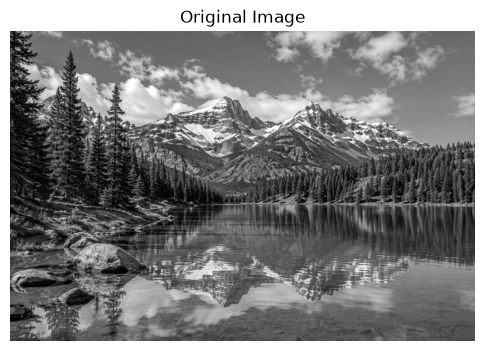

In [9]:
# Load PNG image
image_path = "ex4.png"

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print(" Image not found")
else:
    print(" Image loaded successfully")

    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")
    plt.show()

In [10]:
# Calculate DFT
dft = cv2.dft(np.float32(img), flags=cv2.DFT_COMPLEX_OUTPUT)

print("DFT calculated successfully.")

DFT calculated successfully.


In [11]:
# Shift zero frequency to center
dft_shift = np.fft.fftshift(dft)

print("Frequency shifted to center.")

Frequency shifted to center.


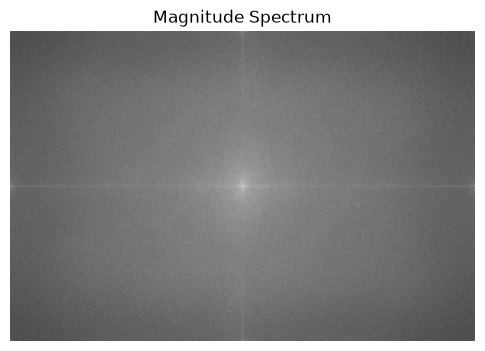

In [12]:
# Calculate magnitude spectrum
magnitude = cv2.magnitude(
    dft_shift[:, :, 0],
    dft_shift[:, :, 1]
)

magnitude_spectrum = 20 * np.log(magnitude + 1)

plt.figure(figsize=(6, 6))
plt.imshow(magnitude_spectrum, cmap="gray")
plt.title("Magnitude Spectrum")
plt.axis("off")
plt.show()

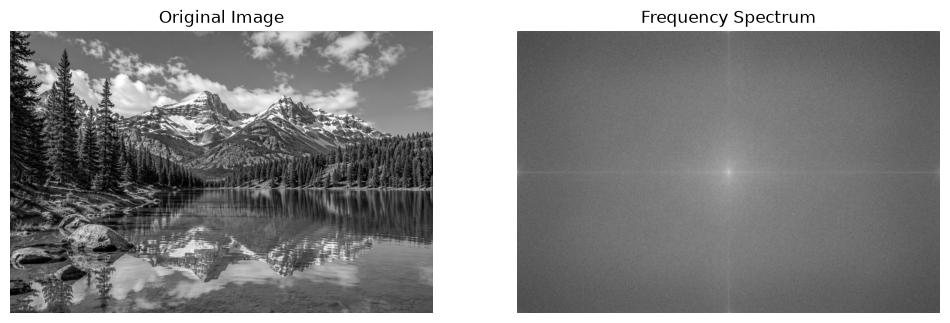

In [13]:
# Compare image and spectrum
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(magnitude_spectrum, cmap="gray")
plt.title("Frequency Spectrum")
plt.axis("off")

plt.show()

In [14]:
# Create Low-Pass Filter
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

radius = 50

mask_low = np.zeros((rows, cols, 2), np.uint8)

cv2.circle(
    mask_low,
    (ccol, crow),
    radius,
    (1, 1),
    -1
)

print("Low-Pass Filter created.")

Low-Pass Filter created.


In [15]:
# Apply Low-Pass Filter
filtered_low = dft_shift * mask_low

print("Low frequencies retained.")

Low frequencies retained.


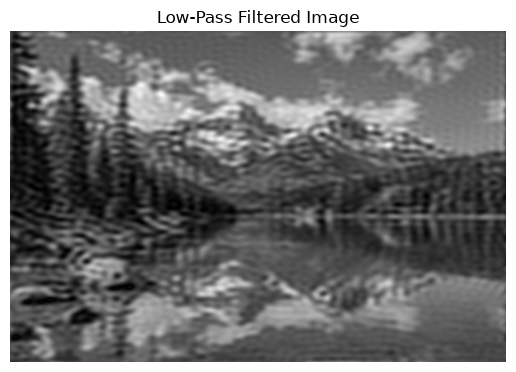

In [16]:
# Shift back
f_ishift_low = np.fft.ifftshift(filtered_low)

# Apply inverse DFT
img_low = cv2.idft(f_ishift_low)

img_low = cv2.magnitude(
    img_low[:, :, 0],
    img_low[:, :, 1]
)

# Normalize image
img_low = cv2.normalize(
    img_low,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

plt.imshow(img_low, cmap="gray")
plt.title("Low-Pass Filtered Image")
plt.axis("off")
plt.show()

In [17]:
# Create High-Pass Filter
mask_high = np.ones((rows, cols, 2), np.uint8)

cv2.circle(
    mask_high,
    (ccol, crow),
    radius,
    (0, 0),
    -1
)

print("High-Pass Filter created.")

High-Pass Filter created.


In [18]:
# Apply High-Pass Filter
filtered_high = dft_shift * mask_high

print("High frequencies retained.")

High frequencies retained.


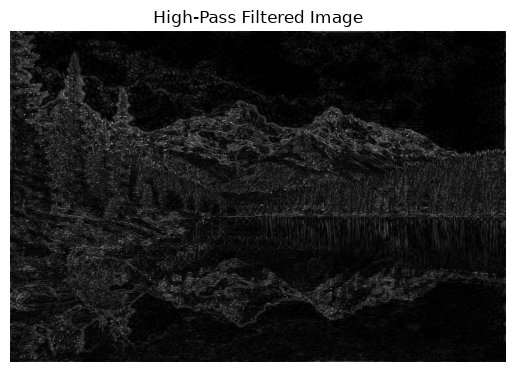

In [19]:
# Shift back
f_ishift_high = np.fft.ifftshift(filtered_high)

# Apply inverse DFT
img_high = cv2.idft(f_ishift_high)

img_high = cv2.magnitude(
    img_high[:, :, 0],
    img_high[:, :, 1]
)

# Normalize image
img_high = cv2.normalize(
    img_high,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

plt.imshow(img_high, cmap="gray")
plt.title("High-Pass Filtered Image")
plt.axis("off")
plt.show()

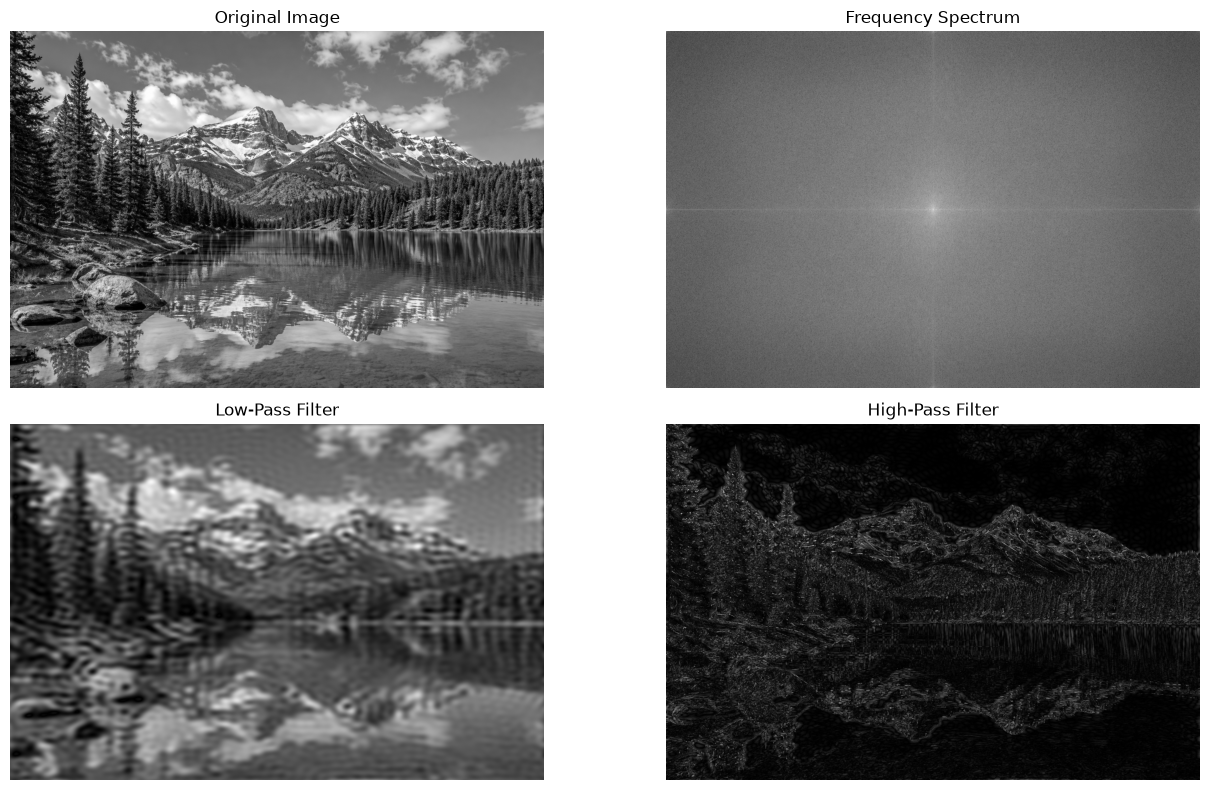

In [20]:
# Compare all results
plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(magnitude_spectrum, cmap="gray")
plt.title("Frequency Spectrum")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(img_low, cmap="gray")
plt.title("Low-Pass Filter")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(img_high, cmap="gray")
plt.title("High-Pass Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
# Save filtered images
cv2.imwrite("low_pass.jpg", img_low)
cv2.imwrite("high_pass.jpg", img_high)

print("Output images saved successfully.")

Output images saved successfully.


In [22]:
# Display observations
print("Observations:")
print("1. Low-Pass Filter makes the image smoother.")
print("2. High-Pass Filter enhances edges and fine details.")
print("3. Frequency spectrum shows image frequency components.")
print("4. Fourier Transform is useful for image enhancement and restoration.")

Observations:
1. Low-Pass Filter makes the image smoother.
2. High-Pass Filter enhances edges and fine details.
3. Frequency spectrum shows image frequency components.
4. Fourier Transform is useful for image enhancement and restoration.
